# Phase 3 - Chunking the Corpus

**Thesis:** *Beyond the Prompt — Comparative Study of Vectorisation and Retrieval
Techniques across Formal and Conversational Financial Narratives.*

This notebook turns the **479 Phase-2 document units** (319 EDGAR section units +
160 earnings units) into retrieval-ready **chunks**, using two strategies:

| Corpus | Strategy | Why |
|---|---|---|
| EDGAR (formal prose, flat text) | recursive character splitting w/ overlap | dense uniform prose; sentence-aware windows |
| Earnings (conversational) | speaker-turn-aware greedy packing | preserves dialogue turns as retrieval units |

**Target:** `chunk_size = 1500`, `overlap = 200`.

### ⚠️ Speaker-turn detection is NOT newline-based
Phase 2 (log #10) established the source earnings transcripts are a **single flat
string with no newlines between turns** — `preserve_newlines=True` was a no-op on
this data. Turns are therefore detected by the source's actual convention: a
capitalised speaker label followed by `" : "` (e.g. `Michael Petters : ...`).
A newline-anchored regex would return **zero** turns and collapse each call into
one unsplittable blob. The `chunkers` module and `tests/test_chunking.py` lock
this in.

### Design invariants (carried from Phase 2)
- Chunks **never span** document units (each parent `doc_id` chunked independently).
- Each chunk **inherits** parent `doc_id` + metadata for retrieval traceability.
- No chunk exceeds `chunk_size` (overlap is counted within budget; it is best-effort).


## 0. Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, time, json
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(override=True) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make `src` importable regardless of where Jupyter is launched from.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

from src.chunking.chunkers import (
    chunk_corpus, save_chunks, load_corpus,
    split_into_speaker_turns, recursive_character_split, chunk_by_speaker_turns,
    DEFAULT_CHUNK_SIZE, DEFAULT_OVERLAP,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

Project root: d:\General IT\AI-ML-LJMU\final_thesis\code


In [3]:
# ---- Config -------------------------------------------------------------
CHUNK_SIZE = 1500
OVERLAP    = 200

# Phase-2 combined-corpus parquet. EDIT this to match your Phase-2 output path
# (the file combine_corpora() / Phase 2 wrote). Common candidates are checked.
CANDIDATE_INPUTS = [
    PROJECT_ROOT / "data/processed/combined_corpus_n200.parquet",
    PROJECT_ROOT / "data/processed/combined_corpus_n100_100.parquet",
    PROJECT_ROOT / "data/processed/combined_corpus.parquet",
    PROJECT_ROOT / "data/processed/corpus_combined_n100_100.parquet",
]
COMBINED_CORPUS_PATH = next((p for p in CANDIDATE_INPUTS if p.exists()),
                            CANDIDATE_INPUTS[0])

OUTPUT_PATH  = PROJECT_ROOT / "data/processed/chunks_n200.parquet"
SUMMARY_PATH = PROJECT_ROOT / "notes/phase_03_chunking_summary.json"
FIG_DIR      = PROJECT_ROOT / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Reading corpus from:", COMBINED_CORPUS_PATH)
print("Will write chunks to:", OUTPUT_PATH)

Reading corpus from: d:\General IT\AI-ML-LJMU\final_thesis\code\data\processed\combined_corpus_n200.parquet
Will write chunks to: d:\General IT\AI-ML-LJMU\final_thesis\code\data\processed\chunks_n200.parquet


## 1. Load the Phase-2 corpus

In [4]:
corpus = load_corpus(COMBINED_CORPUS_PATH)   # deserialises JSON metadata column
print(f"Loaded {len(corpus)} document units")
print("\nBy source:")
print(corpus["source"].value_counts())
print("\nBy (source, subtype):")
print(corpus.groupby(["source", "subtype"]).size())

# Sanity: confirm the Phase-2 counts we expect (319 EDGAR + 160 earnings = 479).
assert len(corpus) == 479, f"expected 479 units, found {len(corpus)} — check input path"
corpus.head(3)

Loaded 479 document units

By source:
source
edgar       319
earnings    160
Name: count, dtype: int64

By (source, subtype):
source    subtype         
earnings  full                40
          prepared_remarks    60
          qa                  60
edgar     section_1           88
          section_1A          84
          section_7           88
          section_8           59
dtype: int64


,doc_id,source,corpus_type,subtype,text,char_length,metadata
0,edgar_0000_section_1,edgar,formal,section_1,"Item 1. Business GENERAL Dominion Energy, headquartered in Richmond, Virginia and inco...",113938,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
1,edgar_0000_section_1A,edgar,formal,section_1A,Item 1A. Risk Factors The Companies’ businesses are influenced by many factors that ar...,55120,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
2,edgar_0000_section_7,edgar,formal,section_7,Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Ope...,100739,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"


## 2. Exploratory chunking on a small sample

Inspect one EDGAR section unit and one earnings unit before chunking everything,
and confirm speaker-turn detection actually fires on the flat earnings text.

In [5]:
# --- one EDGAR unit ---
edgar_unit = corpus[corpus.source == "edgar"].iloc[0]
edgar_chunks = recursive_character_split(edgar_unit["text"], CHUNK_SIZE, OVERLAP)
print(f"[EDGAR] {edgar_unit['doc_id']} | {edgar_unit['char_length']:,} chars "
      f"-> {len(edgar_chunks)} chunks")
print(f"  chunk lengths: min={min(map(len, edgar_chunks))}, "
      f"max={max(map(len, edgar_chunks))}")
print("  first chunk preview:\n   ", edgar_chunks[0][:200], "...")

[EDGAR] edgar_0000_section_1 | 113,938 chars -> 88 chunks
  chunk lengths: min=412, max=1498
  first chunk preview:
    Item 1. Business GENERAL Dominion Energy, headquartered in Richmond, Virginia and incorporated in Virginia in 1983, is one of the nation’s largest producers and distributors of energy. Dominion Energy ...


In [6]:
# --- one earnings unit: verify turn detection on the FLAT string ---
earn_unit = corpus[corpus.source == "earnings"].iloc[0]
turns = split_into_speaker_turns(earn_unit["text"])
print(f"[EARNINGS] {earn_unit['doc_id']} | {earn_unit['char_length']:,} chars")
print(f"  newlines present in text? {chr(10) in earn_unit['text']}")
print(f"  speaker turns detected: {len(turns)}  (must be > 1, not a single blob)")
assert len(turns) > 1, "turn detection failed — see speaker-turn caveat in §0"

earn_chunks = chunk_by_speaker_turns(earn_unit["text"], CHUNK_SIZE, OVERLAP)
print(f"  -> {len(earn_chunks)} chunks; "
      f"max len {max(map(len, earn_chunks))}")
print("  first 3 turns:")
for t in turns[:3]:
    print("    -", t[:70].replace(chr(10), ' '))

[EARNINGS] earnings_0000_prepared | 11,257 chars
  newlines present in text? False
  speaker turns detected: 6  (must be > 1, not a single blob)
  -> 10 chunks; max len 1487
  first 3 turns:
    - Operator : Good day, ladies and gentlemen, and welcome to the Huntingt
    - Dwayne Blake : Thanks, Kyla. Good morning and welcome to the Huntingto
    - Michael Petters : Thanks, Dwayne. Good morning, everyone, and thanks f


## 3. Full-corpus chunking (with timing)

In [7]:
t0 = time.perf_counter()
chunks = chunk_corpus(corpus, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
elapsed = time.perf_counter() - t0

print(f"Chunked {len(corpus)} units -> {len(chunks):,} chunks in {elapsed:.2f}s")
print(f"  ({len(chunks)/elapsed:,.0f} chunks/sec)\n")
print("Chunks by source:")
print(chunks["source"].value_counts())
print("\nChunks by strategy:")
print(chunks["chunk_strategy"].value_counts())
chunks.head(3)

Chunked 479 units -> 21,050 chunks in 0.37s
  (56,345 chunks/sec)

Chunks by source:
source
edgar       16967
earnings     4083
Name: count, dtype: int64

Chunks by strategy:
chunk_strategy
recursive_char    16967
speaker_turn       4083
Name: count, dtype: int64


,chunk_id,doc_id,source,corpus_type,subtype,chunk_index,n_chunks,chunk_strategy,chunk_size_cfg,overlap_cfg,text,char_length,metadata
0,edgar_0000_section_1_chunk_000,edgar_0000_section_1,edgar,formal,section_1,0,88,recursive_char,1500,200,"Item 1. Business GENERAL Dominion Energy, headquartered in Richmond, Virginia and inco...",1464,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
1,edgar_0000_section_1_chunk_001,edgar_0000_section_1,edgar,formal,section_1,1,88,recursive_char,1500,200,Renewable generation facilities are expected to include significant investments in uti...,1462,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
2,edgar_0000_section_1_chunk_002,edgar_0000_section_1,edgar,formal,section_1,2,88,recursive_char,1500,200,"Dominion Energy’s operations are conducted through various subsidiaries, including Vir...",1495,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"


### Eyeballing ten Q&A chunks
Open ten Q&A chunks by eye and confirm no answer got split mid-sentence by a stray Capitalised Word :  pattern.

In [8]:
qa = chunks[chunks.subtype == "qa"].sample(10, random_state=1)
for _, c in qa.iterrows():
    print("="*80)
    print(c["chunk_id"], "|", c["char_length"], "chars")
    print("STARTS:", repr(c["text"][:120]))
    print("ENDS:  ", repr(c["text"][-120:]))

earnings_0032_qa_chunk_018 | 571 chars
STARTS: "Jeremy Tonet : Got it. That's very helpful. Thank you for that. And maybe going back to transmission for a little bit mo"
ENDS:   ' opportunities in the back half of the plan. Any additional thoughts on the cadence of when that could come to fruition?'
earnings_0023_qa_chunk_021 | 1135 chars
STARTS: "Flavia Pease : Yes. And I'll just add. I think NHP pricing is still positive in the first quarter. We are seeing it come"
ENDS:   " that was put out there in March, in terms of how that could benefit local demand in China into your end or perhaps '25?"
earnings_0089_qa_chunk_006 | 1464 chars
STARTS: 'Anirudh Devgan : Also just to add on overall -- yeah, hey, just to add on the overall hardware cycle, as you remember, w'
ENDS:   ' the only solution that does that and provides a unique value. So overall, I think hardware business is performing well.'
earnings_0010_qa_chunk_012 | 730 chars
STARTS: 'Operator : Our next question comes from David P

## 4. Validation invariants (8 checks)

Each is an assertion — the notebook stops if any fails, so a clean run is a
guarantee, not a hope.

In [9]:
checks = []

# 1) No empty / null chunk text.
ok = chunks["text"].notna().all() and (chunks["char_length"] > 0).all()
checks.append(("1. No empty chunks", ok))
assert ok

# 2) No chunk exceeds the configured chunk_size.
ok = (chunks["char_length"] <= CHUNK_SIZE).all()
checks.append((f"2. All chunks <= {CHUNK_SIZE} chars (max={chunks.char_length.max()})", ok))
assert ok

# 3) Every parent document produced at least one chunk (nothing dropped).
ok = set(chunks["doc_id"]) == set(corpus["doc_id"])
checks.append(("3. Every parent doc has >=1 chunk (no docs lost)", ok))
assert ok

# 4) No orphan chunks (every chunk's doc_id exists in the parent corpus).
ok = set(chunks["doc_id"]).issubset(set(corpus["doc_id"]))
checks.append(("4. No orphan chunks", ok))
assert ok

# 5) chunk_index is contiguous 0..k-1 per doc, and n_chunks matches.
contig = True
for _, g in chunks.groupby("doc_id"):
    if sorted(g["chunk_index"]) != list(range(len(g))) or (g["n_chunks"] != len(g)).any():
        contig = False; break
checks.append(("5. chunk_index contiguous & n_chunks correct", contig))
assert contig

# 6) chunks never span documents: chunk_id always startswith its doc_id.
ok = (chunks.apply(lambda r: str(r["chunk_id"]).startswith(str(r["doc_id"])), axis=1)).all()
checks.append(("6. chunk_id prefixed by doc_id (no cross-doc merge)", ok))
assert ok

# 7) Inherited fields match the parent unit exactly.
parent = corpus.set_index("doc_id")[["source", "corpus_type", "subtype"]]
joined = chunks.join(parent, on="doc_id", rsuffix="_parent")
ok = ((joined["source"] == joined["source_parent"]).all()
      and (joined["corpus_type"] == joined["corpus_type_parent"]).all()
      and (joined["subtype"] == joined["subtype_parent"]).all())
checks.append(("7. Inherited source/corpus_type/subtype match parent", ok))
assert ok

# 8) Coverage sanity: total chunk chars >= parent chars (no loss) and
#    <= parent chars * (1 + overlap/chunk_size) + slack (overlap inflation only).
parent_chars = int(corpus["char_length"].sum())
chunk_chars  = int(chunks["char_length"].sum())
upper = parent_chars * (1 + OVERLAP / CHUNK_SIZE) + 2000 * len(corpus) / 1000
ok = parent_chars <= chunk_chars <= upper
checks.append((f"8. Coverage: {parent_chars:,} <= {chunk_chars:,} <= {upper:,.0f}", ok))
assert ok

print("VALIDATION RESULTS")
for name, passed in checks:
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")
print("\nAll 8 invariants hold." if all(p for _, p in checks) else "FAILURES present.")

VALIDATION RESULTS
  [PASS] 1. No empty chunks
  [PASS] 2. All chunks <= 1500 chars (max=1500)
  [PASS] 3. Every parent doc has >=1 chunk (no docs lost)
  [PASS] 4. No orphan chunks
  [PASS] 5. chunk_index contiguous & n_chunks correct
  [PASS] 6. chunk_id prefixed by doc_id (no cross-doc merge)
  [PASS] 7. Inherited source/corpus_type/subtype match parent
  [PASS] 8. Coverage: 26,093,055 <= 27,699,947 <= 29,573,087

All 8 invariants hold.


## 5. Statistics

In [10]:
# Chunks per document unit, by source.
per_doc = chunks.groupby(["source", "doc_id"]).size().rename("n_chunks").reset_index()
print("Chunks per document unit:")
print(per_doc.groupby("source")["n_chunks"].describe()[["mean", "min", "50%", "max"]])

print("\nChunk char length, by source:")
print(chunks.groupby("source")["char_length"].describe()[["mean", "min", "50%", "max"]])

print("\nChunks per earnings subtype (mean per doc):")
earn = per_doc[per_doc.source == "earnings"].merge(
    corpus[["doc_id", "subtype"]], on="doc_id")
print(earn.groupby("subtype")["n_chunks"].mean())

Chunks per document unit:
               mean  min   50%    max
source                               
earnings  25.518750  3.0  23.0   71.0
edgar     53.188088  1.0  42.0  323.0

Chunk char length, by source:
                 mean   min     50%     max
source                                     
earnings  1190.395787  41.0  1333.0  1500.0
edgar     1346.116638   8.0  1395.0  1499.0

Chunks per earnings subtype (mean per doc):
subtype
full                36.825000
prepared_remarks    17.183333
qa                  26.316667
Name: n_chunks, dtype: float64


## 6. Visualisation

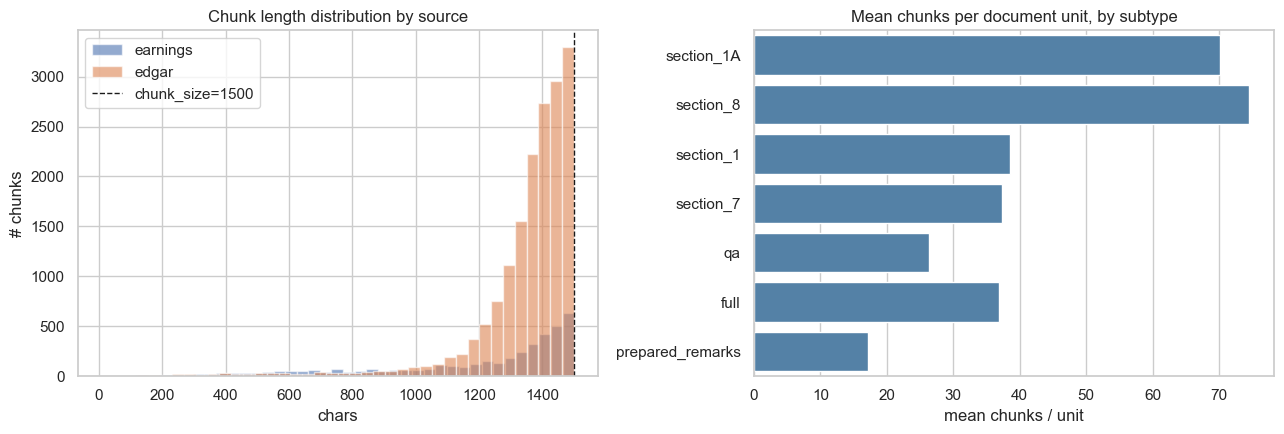

Saved figure -> d:\General IT\AI-ML-LJMU\final_thesis\code\reports\figures\phase03_chunk_distributions.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) chunk length distribution by source
for src, sub in chunks.groupby("source"):
    axes[0].hist(sub["char_length"], bins=40, alpha=0.6, label=src)
axes[0].axvline(CHUNK_SIZE, color="k", ls="--", lw=1, label=f"chunk_size={CHUNK_SIZE}")
axes[0].set_title("Chunk length distribution by source")
axes[0].set_xlabel("chars"); axes[0].set_ylabel("# chunks"); axes[0].legend()

# (b) mean chunks per parent unit by subtype
order = chunks.groupby("subtype").size().sort_values(ascending=False).index
cpd = chunks.groupby(["subtype", "doc_id"]).size().groupby("subtype").mean().reindex(order)
sns.barplot(x=cpd.values, y=cpd.index, ax=axes[1], color="steelblue")
axes[1].set_title("Mean chunks per document unit, by subtype")
axes[1].set_xlabel("mean chunks / unit"); axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "phase03_chunk_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure ->", FIG_DIR / "phase03_chunk_distributions.png")

## 7. Save chunked corpus + summary

In [12]:
save_chunks(chunks, OUTPUT_PATH)
print(f"Saved {len(chunks):,} chunks -> {OUTPUT_PATH}")

# Round-trip check: reload and confirm metadata deserialises.
_reload = load_corpus(OUTPUT_PATH)
assert len(_reload) == len(chunks)
assert isinstance(_reload.iloc[0]["metadata"], dict)
print("Round-trip OK (metadata reloads as dict).")

Saved 21,050 chunks -> d:\General IT\AI-ML-LJMU\final_thesis\code\data\processed\chunks_n200.parquet
Round-trip OK (metadata reloads as dict).


In [13]:
def _per_doc_stats(df, src):
    s = df[df.source == src].groupby("doc_id").size()
    return {} if s.empty else {
        "n_parent_units": int(s.shape[0]),
        "n_chunks": int(s.sum()),
        "chunks_per_unit_mean": round(float(s.mean()), 2),
        "chunks_per_unit_min": int(s.min()),
        "chunks_per_unit_max": int(s.max()),
        "chunk_chars_mean": round(float(df[df.source == src]["char_length"].mean()), 1),
    }

summary = {
    "phase": 3,
    "config": {"chunk_size": CHUNK_SIZE, "overlap": OVERLAP,
               "strategies": {"edgar": "recursive_char", "earnings": "speaker_turn"}},
    "input_units": int(len(corpus)),
    "total_chunks": int(len(chunks)),
    "by_source": {s: int(n) for s, n in chunks["source"].value_counts().items()},
    "by_subtype": {s: int(n) for s, n in chunks["subtype"].value_counts().items()},
    "edgar": _per_doc_stats(chunks, "edgar"),
    "earnings": _per_doc_stats(chunks, "earnings"),
    "invariants_passed": int(sum(1 for _, p in checks if p)),
    "invariants_total": len(checks),
    "timing_seconds": round(elapsed, 2),
    "speaker_turn_detection": "label_regex(' : ')_not_newline",
    "output_path": str(OUTPUT_PATH.relative_to(PROJECT_ROOT)),
}
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nSaved summary ->", SUMMARY_PATH)

{
  "phase": 3,
  "config": {
    "chunk_size": 1500,
    "overlap": 200,
    "strategies": {
      "edgar": "recursive_char",
      "earnings": "speaker_turn"
    }
  },
  "input_units": 479,
  "total_chunks": 21050,
  "by_source": {
    "edgar": 16967,
    "earnings": 4083
  },
  "by_subtype": {
    "section_1A": 5898,
    "section_8": 4398,
    "section_1": 3392,
    "section_7": 3279,
    "qa": 1579,
    "full": 1473,
    "prepared_remarks": 1031
  },
  "edgar": {
    "n_parent_units": 319,
    "n_chunks": 16967,
    "chunks_per_unit_mean": 53.19,
    "chunks_per_unit_min": 1,
    "chunks_per_unit_max": 323,
    "chunk_chars_mean": 1346.1
  },
  "earnings": {
    "n_parent_units": 160,
    "n_chunks": 4083,
    "chunks_per_unit_mean": 25.52,
    "chunks_per_unit_min": 3,
    "chunks_per_unit_max": 71,
    "chunk_chars_mean": 1190.4
  },
  "invariants_passed": 8,
  "invariants_total": 8,
  "timing_seconds": 0.37,
  "speaker_turn_detection": "label_regex(' : ')_not_newline",
  "outpu

## Exporting sample rows from the parquet, so it sees the real chunk shape

In [15]:
# --- Export 20 sample chunks for the next-phase chat (schema visibility) ---
sample = (chunks.groupby("source", group_keys=False)
          .head(10)                       # 10 EDGAR + 10 earnings, no apply needed
          .copy())

# Trim text so the CSV stays readable (shape matters, not full content)
sample["text_preview"] = sample["text"].str.slice(0, 300) + "..."

cols = ["chunk_id", "doc_id", "source", "subtype", "chunk_index",
        "n_chunks", "char_length", "text_preview", "metadata"]
sample_out = sample[cols]

sample_path = PROJECT_ROOT / "notes/chunks_sample_20.csv"
sample_out.to_csv(sample_path, index=False)
print(f"Wrote {len(sample_out)} sample chunks -> {sample_path}")
sample_out.head()

Wrote 20 sample chunks -> d:\General IT\AI-ML-LJMU\final_thesis\code\notes\chunks_sample_20.csv


,chunk_id,doc_id,source,subtype,chunk_index,n_chunks,char_length,text_preview,metadata
0,edgar_0000_section_1_chunk_000,edgar_0000_section_1,edgar,section_1,0,88,1464,"Item 1. Business GENERAL Dominion Energy, headquartered in Richmond, Virginia and inco...","{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
1,edgar_0000_section_1_chunk_001,edgar_0000_section_1,edgar,section_1,1,88,1462,Renewable generation facilities are expected to include significant investments in uti...,"{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
2,edgar_0000_section_1_chunk_002,edgar_0000_section_1,edgar,section_1,2,88,1495,"Dominion Energy’s operations are conducted through various subsidiaries, including Vir...","{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
3,edgar_0000_section_1_chunk_003,edgar_0000_section_1,edgar,section_1,3,88,1357,"In addition, Virginia Power sells and transmits electricity at wholesale prices to rur...","{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"
4,edgar_0000_section_1_chunk_004,edgar_0000_section_1,edgar,section_1,4,88,1387,"Information contained on Dominion Energy’s website, including but not limited to repor...","{'filename': '103682_2020.htm', 'cik': '103682', 'year': '2020', 'filing_idx': 0}"


## 8. Next step - Phase 4 (BM25 baseline)

`data/processed/chunks_n200.parquet` is now the retrieval unit for every config
(sparse / dense / hybrid), so all three retrievers index the *same* chunks -
preserving comparative validity. Phase 4: build the BM25 index over these chunks
and measure Precision@K / Recall@K / MRR.

**Carry-forward limitation:** speaker-turn detection is heuristic (label regex).
Spot-check a handful of QA chunks for mid-sentence false splits before scale-up
to n=500; documented in `phase_03_log.md`.